In [ ]:
# Import the pandas library
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv("heart.csv")

# Display the first five rows of the dataset
print("First 5 Rows of the Dataset:")
print(df.head())

# Get the number of rows and columns
rows, columns = df.shape

# Display the dataset dimensions
print(f"\nNumber of Rows: {rows}")
print(f"Number of Columns: {columns}")

First 5 Rows of the Dataset:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Number of Rows: 918
Number of Columns: 12


In [ ]:
# ==========================================
# Check Class Distribution
# ==========================================

print("HeartDisease Class Distribution")
print(df["HeartDisease"].value_counts())

print("\nPercentage Distribution")
print(df["HeartDisease"].value_counts(normalize=True) * 100)

HeartDisease Class Distribution
HeartDisease
1    508
0    410
Name: count, dtype: int64

Percentage Distribution
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [ ]:
## Class Distribution Analysis

Before training the model, the class distribution of the target variable (`HeartDisease`) was examined to determine whether the dataset was imbalanced.

- Heart Disease (1): **508 records (55.34%)**
- No Heart Disease (0): **410 records (44.66%)**

The dataset is reasonably balanced. Therefore, **SMOTE was not applied**, since oversampling was unnecessary and could introduce synthetic patterns without improving model performance.

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
import pandas as pd
df = pd.read_csv("heart.csv")
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
import pandas as pd
import os
import shutil

os.makedirs("raw", exist_ok=True)
os.makedirs("gold", exist_ok=True)

df = pd.read_csv("heart.csv")
shutil.copy("heart.csv", "raw/original_dataset.csv")

print("========== EXTRACT ==========")
print("Dataset Loaded Successfully")
print(f"Dataset Shape: {df.shape}")

print("\nFirst Five Rows:")
print(df.head())

print("\n========== INSPECT ==========")

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\n========== TRANSFORM ==========")

df = df.drop_duplicates()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].mean())

for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].astype(str)

df.columns = df.columns.str.lower()

print("Data Cleaning Completed Successfully.")

print("\n========== VALIDATE ==========")

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nRemaining Duplicate Records:")
print(df.duplicated().sum())

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

output_path = "gold/clean_data.csv"
df.to_csv(output_path, index=False)

print("\n========== LOAD ==========")
print(f"Cleaned dataset saved successfully at: {output_path}")
print(f"Final Dataset Shape: {df.shape}")

========== EXTRACT ==========
Dataset Loaded Successfully
Dataset Shape: (918, 12)

First Five Rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

========== INSPECT ==========

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918

In [ ]:
import sqlite3
import pandas as pd

df = pd.read_csv("gold/clean_data.csv")

conn = sqlite3.connect("heart_failure.db")
cursor = conn.cursor()
for _, row in df.iterrows():
    cursor.execute("""
            INSERT INTO Patient(age, sex)
            VALUES (?, ?)
        """, (
            int(row["age"]),
            row["sex"]
        ))
    patient_id = cursor.lastrowid
    cursor.execute("""
            INSERT INTO MedicalHistory
            (patient_id, fasting_bs, exercise_angina, heart_disease)
            VALUES (?, ?, ?, ?)
        """, (
            patient_id,
            int(row["fastingbs"]),
            row["exerciseangina"],
            int(row["heartdisease"])
        ))
    cursor.execute("""
            INSERT INTO ClinicalMeasurements
            (patient_id, resting_bp, cholesterol, max_hr, oldpeak)
            VALUES (?, ?, ?, ?, ?)
        """, (
            patient_id,
            int(row["restingbp"]),
            int(row["cholesterol"]),
            int(row["maxhr"]),
            float(row["oldpeak"])
        ))
    cursor.execute("""
            INSERT INTO ECGDetails
            (patient_id, chest_pain_type, resting_ecg, st_slope)
            VALUES (?, ?, ?, ?)
        """, (
            patient_id,
            row["chestpaintype"],
            row["restingecg"],
            row["st_slope"]
        ))
conn.commit()

print("Database created successfully.")
print("All records inserted successfully.")

cursor.execute("SELECT COUNT(*) FROM Patient")
print("Patient Records:", cursor.fetchone()[0])
conn.close()

Database created successfully.
All records inserted successfully.
Patient Records: 2754


In [ ]:
import pandas as pd

df = pd.read_csv("gold/clean_data.csv")
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
stats = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Standard Deviation": df[numerical_columns].std(),
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max()
})
print("\nNumerical Columns Statistics:\n")
print(stats)
categorical_columns = df.select_dtypes(include=['object']).columns
print("\n" + "="*60)
print("VALUE COUNTS FOR CATEGORICAL COLUMNS")
print("="*60)

for column in categorical_columns:
    print(f"\nColumn: {column}")
    print(df[column].value_counts())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage
})
print(missing_df)

DESCRIPTIVE STATISTICS

Numerical Columns Statistics:

                    Mean  Median  Standard Deviation  Minimum  Maximum
age            53.510893    54.0            9.432617     28.0     77.0
restingbp     132.396514   130.0           18.514154      0.0    200.0
cholesterol   198.799564   223.0          109.384145      0.0    603.0
fastingbs       0.233115     0.0            0.423046      0.0      1.0
maxhr         136.809368   138.0           25.460334     60.0    202.0
oldpeak         0.887364     0.6            1.066570     -2.6      6.2
heartdisease    0.553377     1.0            0.497414      0.0      1.0

VALUE COUNTS FOR CATEGORICAL COLUMNS

Column: sex
sex
M    725
F    193
Name: count, dtype: int64

Column: chestpaintype
chestpaintype
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

Column: restingecg
restingecg
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

Column: exerciseangina
exerciseangina
N    547
Y    371
Name: count, dt

In [ ]:
print(df.describe)

<bound method NDFrame.describe of      age sex chestpaintype  restingbp  cholesterol  fastingbs restingecg  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     maxhr exerciseangina  oldpeak st_slope  heartdis

Generating Histograms...


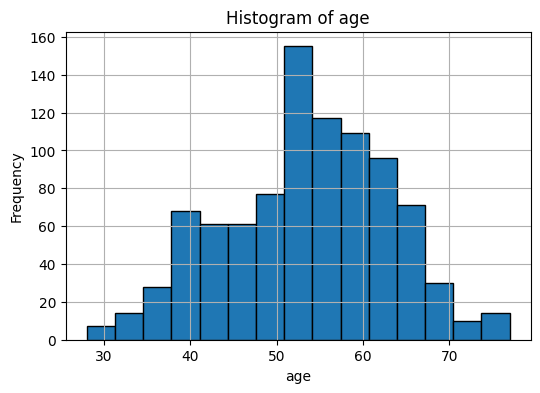

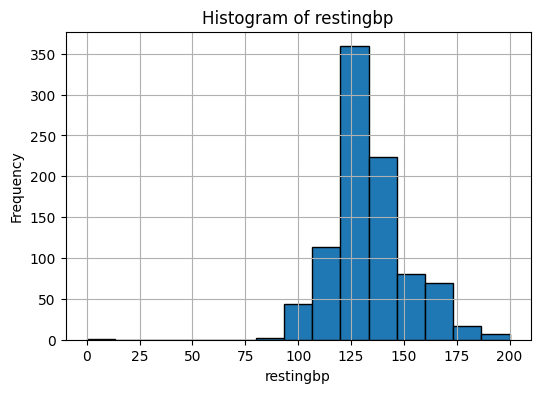

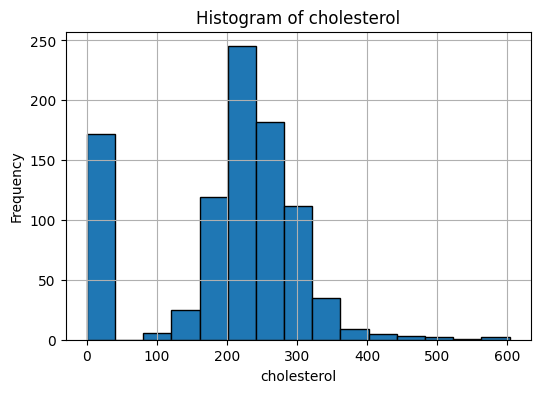

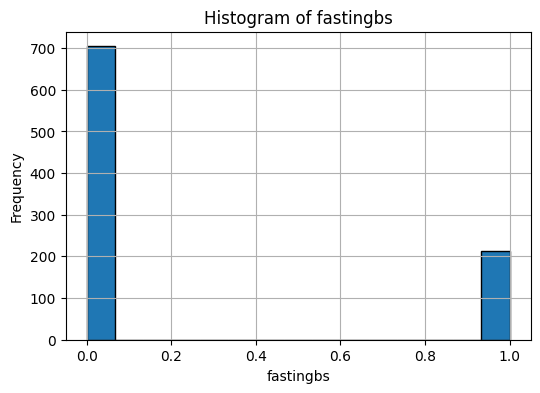

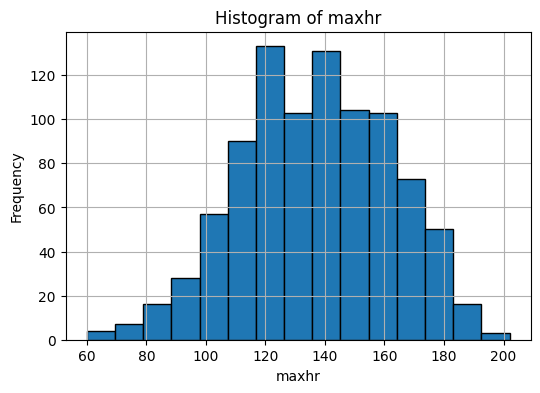

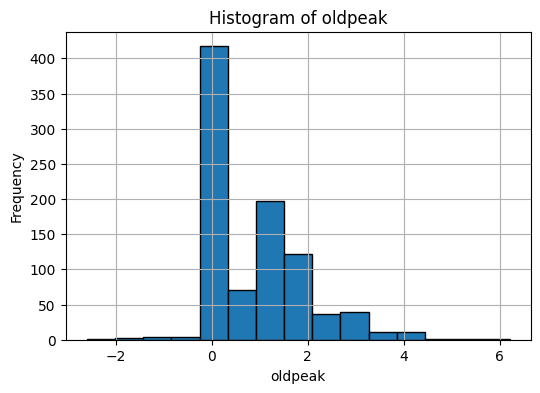

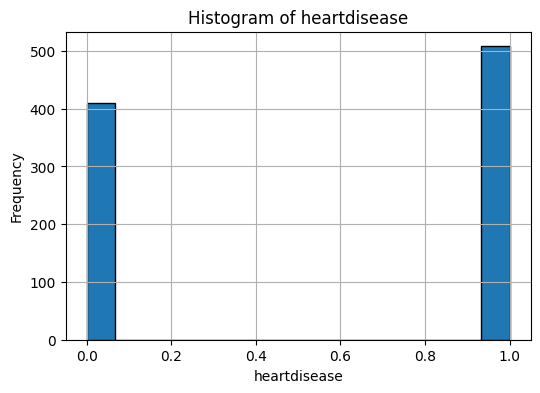

Generating Boxplots...


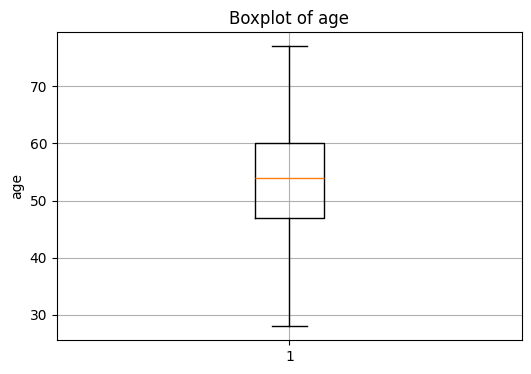

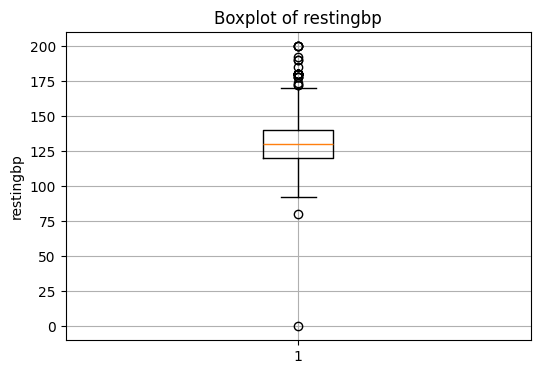

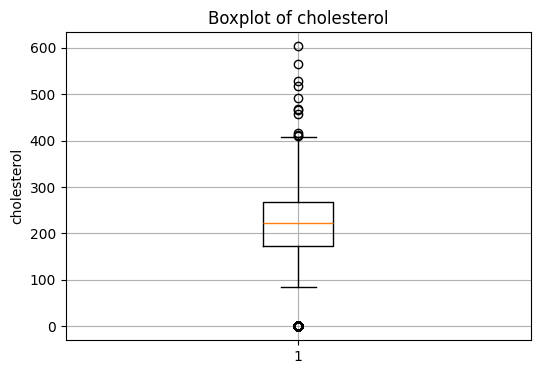

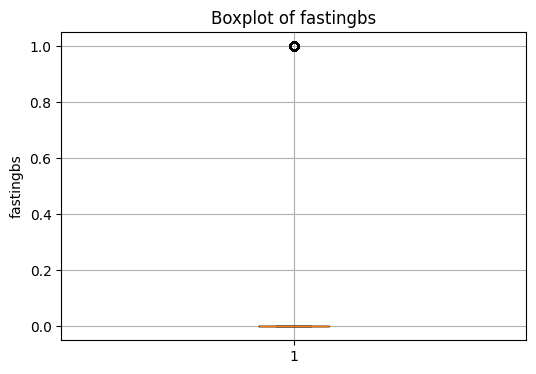

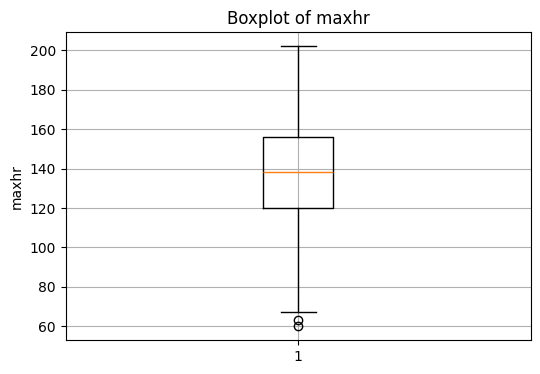

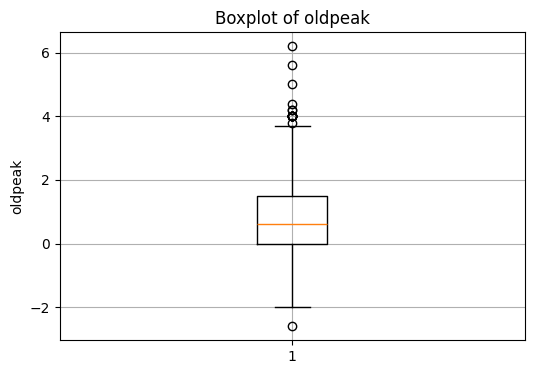

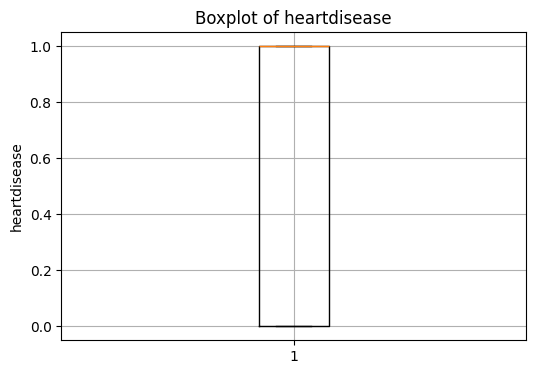

Generating Bar Charts...


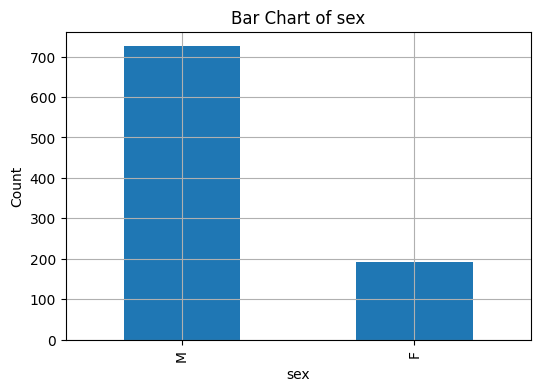

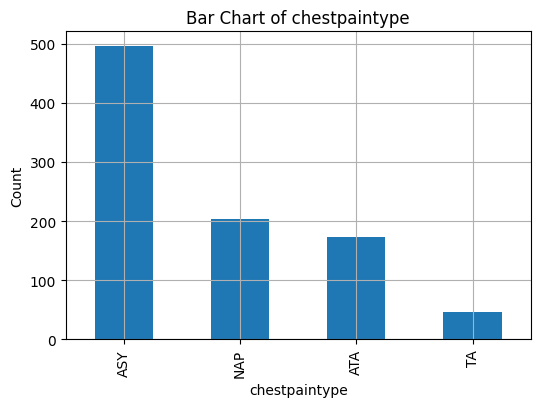

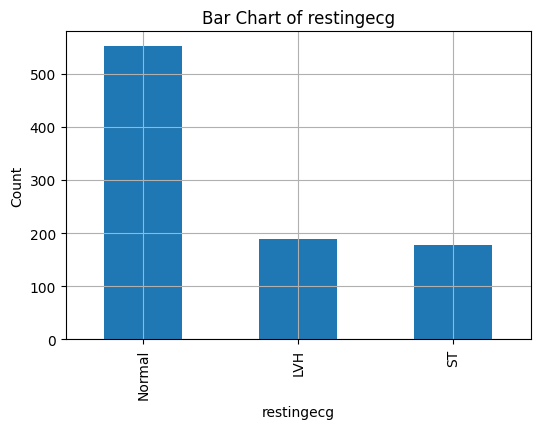

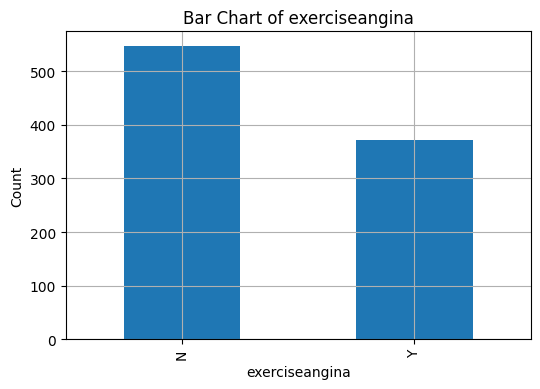

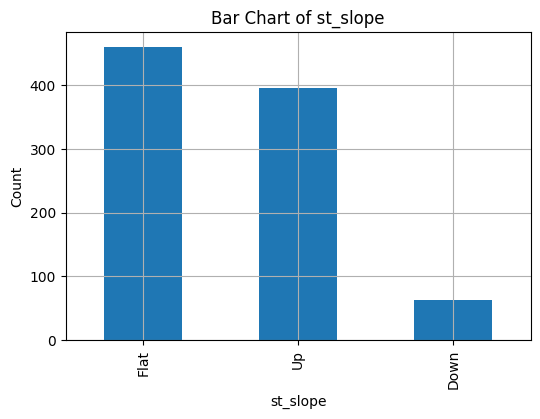

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("gold/clean_data.csv")

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns
print("Generating Histograms...")

for column in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[column], bins=15, edgecolor='black')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()
print("Generating Boxplots...")

for column in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[column], vert=True)
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.grid(True)
    plt.show()
print("Generating Bar Charts...")

for column in categorical_columns:
    plt.figure(figsize=(6,4))
    df[column].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()

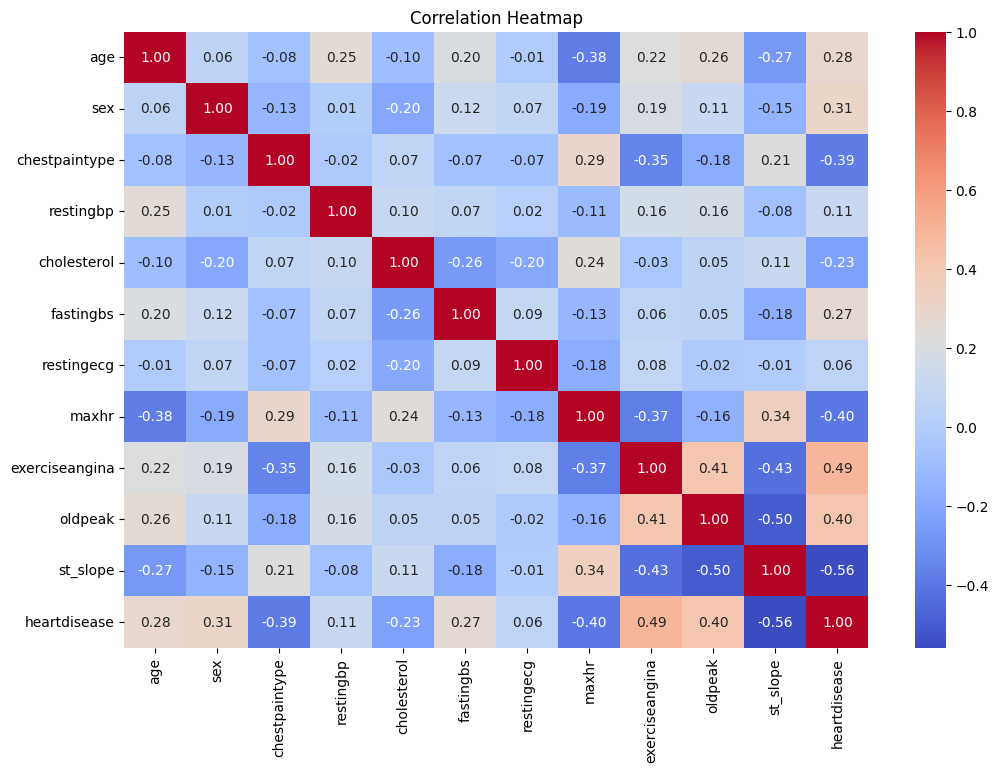

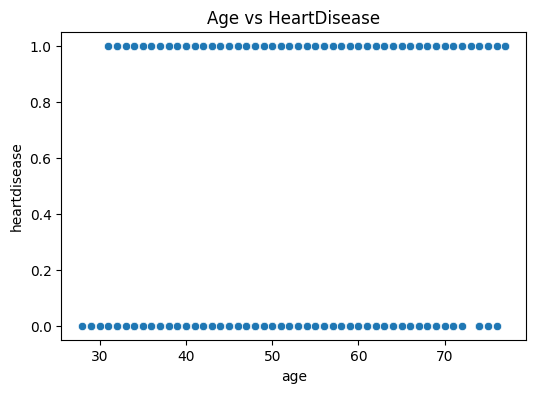

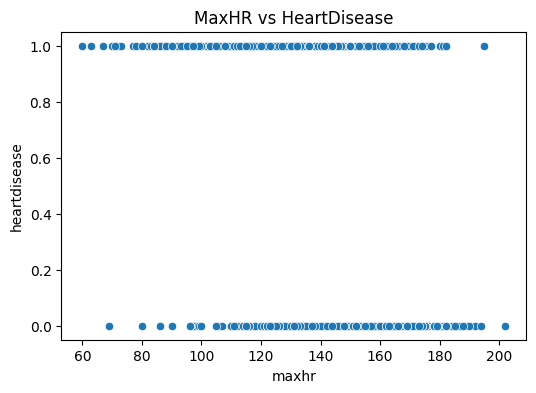

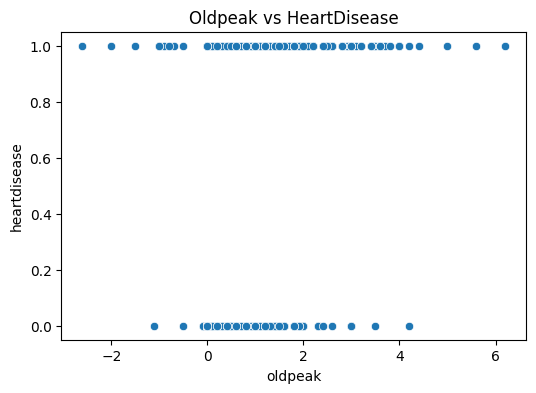

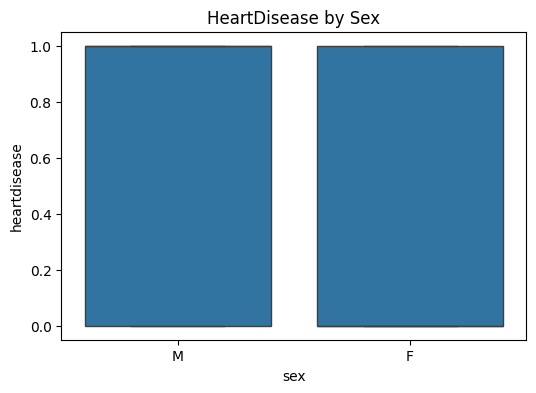

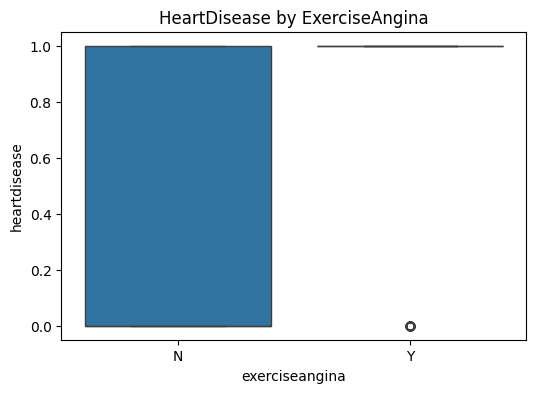

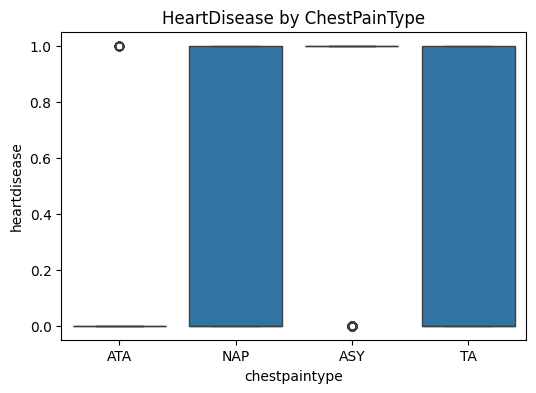

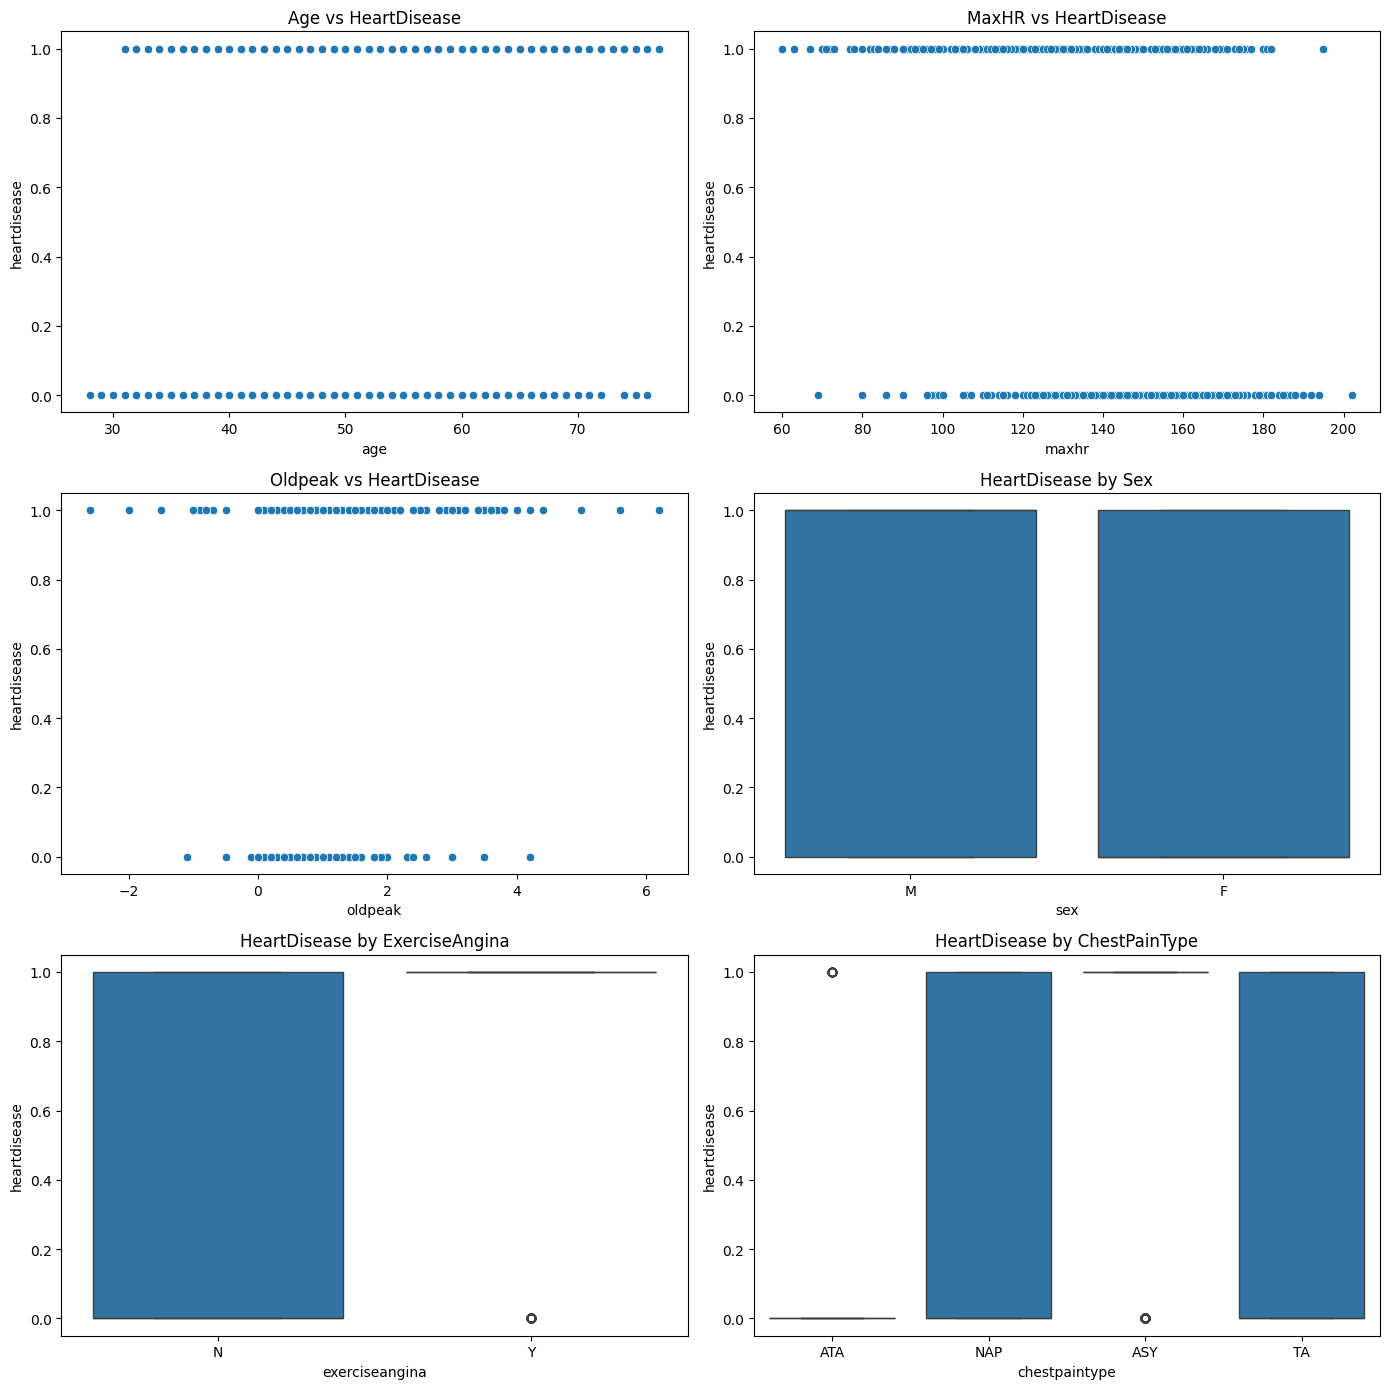

Top 3 Strongest Predictors:
st_slope          0.558771
exerciseangina    0.494282
oldpeak           0.403951
Name: heartdisease, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("heart.csv")

df.columns = df.columns.str.lower()

df_encoded = df.copy()

categorical_cols = ['sex', 'chestpaintype', 'restingecg',
                    'exerciseangina', 'st_slope']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df,
                x="age",
                y="heartdisease")
plt.title("Age vs HeartDisease")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df,
                x="maxhr",
                y="heartdisease")
plt.title("MaxHR vs HeartDisease")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df,
                x="oldpeak",
                y="heartdisease")
plt.title("Oldpeak vs HeartDisease")
plt.show()
plt.figure(figsize=(6,4))
sns.boxplot(data=df,
            x="sex",
            y="heartdisease")
plt.title("HeartDisease by Sex")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df,
            x="exerciseangina",
            y="heartdisease")
plt.title("HeartDisease by ExerciseAngina")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df,
            x="chestpaintype",
            y="heartdisease")
plt.title("HeartDisease by ChestPainType")
plt.show()

fig, axes = plt.subplots(3,2, figsize=(14,14))

sns.scatterplot(data=df,
                x="age",
                y="heartdisease",
                ax=axes[0,0])

axes[0,0].set_title("Age vs HeartDisease")

sns.scatterplot(data=df,
                x="maxhr",
                y="heartdisease",
                ax=axes[0,1])

axes[0,1].set_title("MaxHR vs HeartDisease")

sns.scatterplot(data=df,
                x="oldpeak",
                y="heartdisease",
                ax=axes[1,0])

axes[1,0].set_title("Oldpeak vs HeartDisease")

sns.boxplot(data=df,
            x="sex",
            y="heartdisease",
            ax=axes[1,1])

axes[1,1].set_title("HeartDisease by Sex")

sns.boxplot(data=df,
            x="exerciseangina",
            y="heartdisease",
            ax=axes[2,0])

axes[2,0].set_title("HeartDisease by ExerciseAngina")

sns.boxplot(data=df,
            x="chestpaintype",
            y="heartdisease",
            ax=axes[2,1])

axes[2,1].set_title("HeartDisease by ChestPainType")

plt.tight_layout()
plt.show()

correlation = df_encoded.corr()["heartdisease"].abs().sort_values(ascending=False)

print("Top 3 Strongest Predictors:")
print(correlation[1:4])

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("heart.csv")

print("="*60)
print("HYPOTHESIS 1")
print("Older patients are more likely to have heart disease.\n")

result = df.groupby("HeartDisease")["Age"].mean()

print(result)

if result[1] > result[0]:
    print("\nConclusion: SUPPORTED")
else:
    print("\nConclusion: NOT SUPPORTED")

print("\n"+"="*60)
print("HYPOTHESIS 2")
print("Higher cholesterol increases heart disease risk.\n")

result = df.groupby("HeartDisease")["Cholesterol"].mean()

print(result)

if result[1] > result[0]:
    print("\nConclusion: SUPPORTED")
else:
    print("\nConclusion: NOT SUPPORTED")

print("\n"+"="*60)
print("HYPOTHESIS 3")
print("Lower MaxHR is associated with heart disease.\n")

result = df.groupby("HeartDisease")["MaxHR"].mean()

print(result)

if result[1] < result[0]:
    print("\nConclusion: SUPPORTED")
else:
    print("\nConclusion: NOT SUPPORTED")

print("\n"+"="*60)
print("HYPOTHESIS 4")
print("Exercise-induced angina increases heart disease risk.\n")

result = df.groupby("ExerciseAngina")["HeartDisease"].mean()

print(result)

if result["Y"] > result["N"]:
    print("\nConclusion: SUPPORTED")
else:
    print("\nConclusion: NOT SUPPORTED")

print("\n"+"="*60)
print("HYPOTHESIS 5")
print("Chest pain type influences heart disease occurrence.\n")

result = df.groupby("ChestPainType")["HeartDisease"].mean()

print(result)

print("\nConclusion: Compare the average HeartDisease values for each ChestPainType.")

HYPOTHESIS 1
Older patients are more likely to have heart disease.

HeartDisease
0    50.551220
1    55.899606
Name: Age, dtype: float64

Conclusion: SUPPORTED

HYPOTHESIS 2
Higher cholesterol increases heart disease risk.

HeartDisease
0    227.121951
1    175.940945
Name: Cholesterol, dtype: float64

Conclusion: NOT SUPPORTED

HYPOTHESIS 3
Lower MaxHR is associated with heart disease.

HeartDisease
0    148.151220
1    127.655512
Name: MaxHR, dtype: float64

Conclusion: SUPPORTED

HYPOTHESIS 4
Exercise-induced angina increases heart disease risk.

ExerciseAngina
N    0.351005
Y    0.851752
Name: HeartDisease, dtype: float64

Conclusion: SUPPORTED

HYPOTHESIS 5
Chest pain type influences heart disease occurrence.

ChestPainType
ASY    0.790323
ATA    0.138728
NAP    0.354680
TA     0.434783
Name: HeartDisease, dtype: float64

Conclusion: Compare the average HeartDisease values for each ChestPainType.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
df = pd.read_csv("heart.csv")

label_encoder = LabelEncoder()
categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    roc_auc = roc_auc_score(y_test, probability)

    cv = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    ).mean()
    results.append([
          name,
              accuracy,
                  precision,
                      recall,
                          f1,
                              roc_auc,
                                  cv
                                  ]
    )
comparison = pd.DataFrame(
    results,
   columns=[
        "Model",
            "Accuracy",
                "Precision",
                    "Recall",
                        "F1-Score",
                            "ROC-AUC",
                                "Cross Validation Accuracy"
                                ]
   ]
)

print("\nModel Comparison\n")
print(comparison)

best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("\nBest Model")
print(best_model)



Model Comparison

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0  Logistic Regression  0.842391   0.906250  0.813084  0.857143  0.901202   
1        Random Forest  0.880435   0.897196  0.897196  0.897196  0.942954   
2    Gradient Boosting  0.875000   0.920000  0.859813  0.888889  0.937492   

   Cross Validation Accuracy  
0                   0.807151  
1                   0.822363  
2                   0.820189  

Best Model
Model                        Random Forest
Accuracy                          0.880435
Precision                         0.897196
Recall                            0.897196
F1-Score                          0.897196
ROC-AUC                           0.942954
Cross Validation Accuracy         0.822363
Name: 1, dtype: object


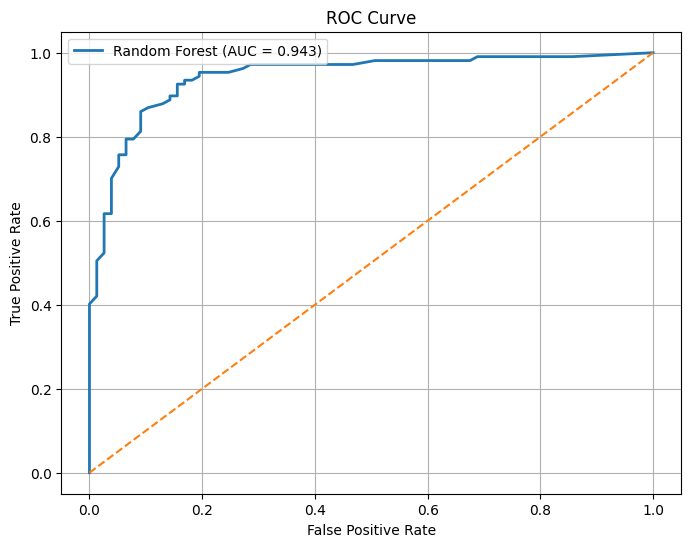

In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Train Random Forest Model
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

# Predict probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f"Random Forest (AUC = {roc_auc:.3f})",
         linewidth=2)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

# Save the graph
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

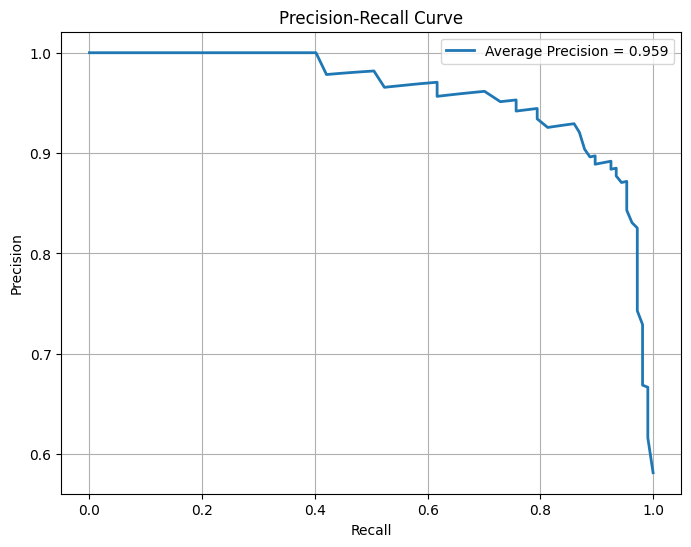

In [ ]:
## Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# Get prediction probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate Average Precision
ap_score = average_precision_score(y_test, y_prob)

# Plot Precision-Recall Curve
plt.figure(figsize=(8,6))

plt.plot(
    recall,
        precision,
            linewidth=2,
                label=f"Average Precision = {ap_score:.3f}"
                )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
## Save Trained Model
# ==========================================
# Save Trained Random Forest Model
# ==========================================

import joblib

# Train the final model
final_model = RandomForestClassifier(
    random_state=42
    )

final_model.fit(X_train, y_train)

# Save the trained model
joblib.dump(final_model, "heart_model.pkl")

print("✅ Model saved successfully as heart_model.pkl")

✅ Model saved successfully as heart_model.pkl


In [ ]:
import joblib

encoders = {}

# Encode and save each categorical column
for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    encoders[column] = encoder

# Save all encoders
joblib.dump(encoders, "label_encoders.pkl")

print("✅ Label encoders saved successfully as label_encoders.pkl")

✅ Label encoders saved successfully as label_encoders.pkl



Feature Importance Scores

           Feature  Importance
10        ST_Slope    0.241312
9          Oldpeak    0.123073
4      Cholesterol    0.107227
7            MaxHR    0.103848
8   ExerciseAngina    0.100046
2    ChestPainType    0.092671
0              Age    0.085520
3        RestingBP    0.066473
1              Sex    0.033963
6       RestingECG    0.026302
5        FastingBS    0.019565


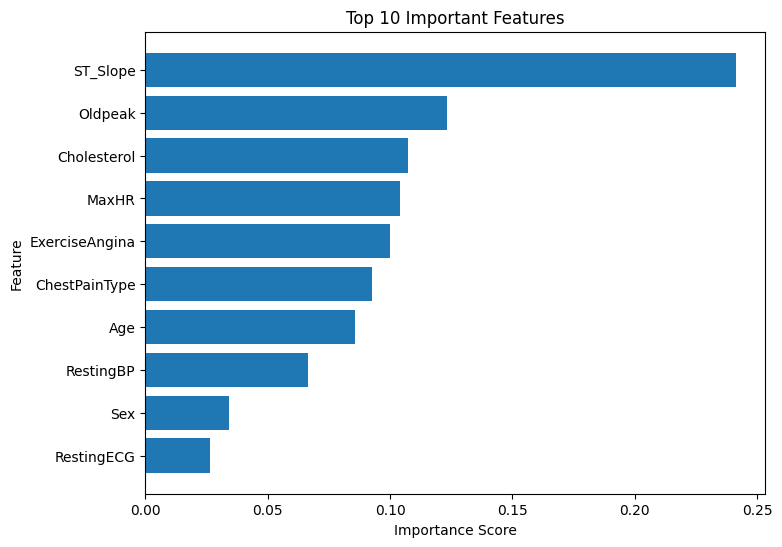


Features with Importance < 0.01

Empty DataFrame
Columns: [Feature, Importance]
Index: []


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("heart.csv")
encoder = LabelEncoder()

categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance Scores\n")
print(importance)

top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

# Save the graph
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

low_features = importance[
    importance["Importance"] < 0.01
]

print("\nFeatures with Importance < 0.01\n")
print(low_features)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

df = pd.read_csv("heart.csv")

encoder = LabelEncoder()
categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

lr = LogisticRegression(max_iter=5000)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)

    cv = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    ).mean()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        cv
    ])

estimators = [
    ("lr", lr),
    ("rf", rf),
    ("gb", gb)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=5000)
)

stack_model.fit(X_train, y_train)

stack_prediction = stack_model.predict(X_test)

accuracy = accuracy_score(y_test, stack_prediction)
precision = precision_score(y_test, stack_prediction)
recall = recall_score(y_test, stack_prediction)
f1 = f1_score(y_test, stack_prediction)

cv = cross_val_score(
    stack_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
).mean()

results.append([
    "Stacking Classifier",
    accuracy,
    precision,
    recall,
    f1,
    cv
])

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Cross Validation Accuracy"
    ]
)

print("\nModel Performance Comparison\n")
print(comparison)

best = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("\nBest Performing Model")
print(best)



Model Performance Comparison

                 Model  Accuracy  Precision    Recall  F1-Score  \
0  Logistic Regression  0.842391   0.906250  0.813084  0.857143   
1        Random Forest  0.880435   0.897196  0.897196  0.897196   
2    Gradient Boosting  0.875000   0.920000  0.859813  0.888889   
3  Stacking Classifier  0.880435   0.904762  0.887850  0.896226   

   Cross Validation Accuracy  
0                   0.807151  
1                   0.822363  
2                   0.820189  
3                   0.821288  

Best Performing Model
Model                        Random Forest
Accuracy                          0.880435
Precision                         0.897196
Recall                            0.897196
F1-Score                          0.897196
Cross Validation Accuracy         0.822363
Name: 1, dtype: object


Generating SHAP Summary Plot...


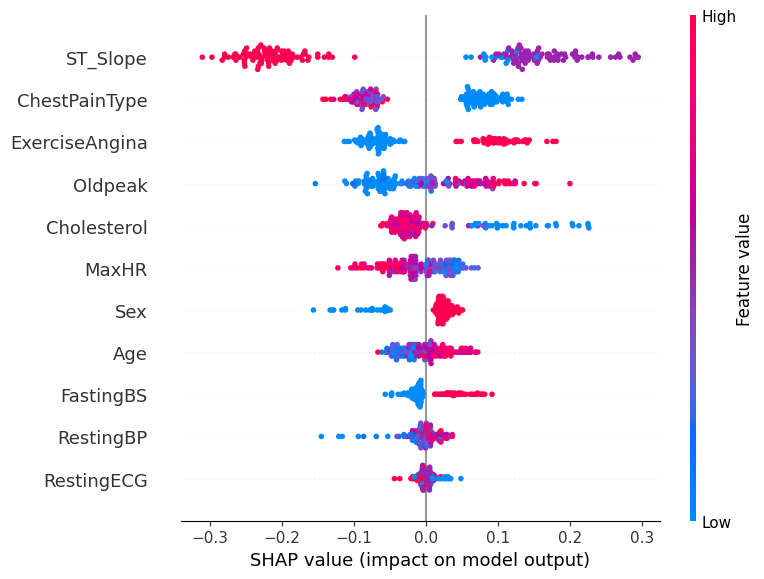

Generating SHAP Force Plot...


In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("heart.csv")
encoder = LabelEncoder()
categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print("Generating SHAP Summary Plot...")
shap.summary_plot(
    shap_values[:,:,1],
    X_test
)
print("Generating SHAP Force Plot...")
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values[0,:,1],
    X_test.iloc[0]
)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
df = pd.read_csv("heart.csv")
encoder = LabelEncoder()
categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

cv_accuracy = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
).mean()
gap = train_accuracy - test_accuracy

parameters = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15,None],
    "min_samples_split":[2,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_
train_pred2 = best_model.predict(X_train)
test_pred2 = best_model.predict(X_test)

train_accuracy2 = accuracy_score(y_train,train_pred2)
test_accuracy2 = accuracy_score(y_test,test_pred2)

cv_accuracy2 = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
).mean()

gap2 = train_accuracy2-test_accuracy2
comparison = pd.DataFrame({
    "Model":[
        "Random Forest (Before Tuning)",
        "Random Forest (After Tuning)"
    ],
    "Training Accuracy":[
        train_accuracy,
        train_accuracy2
    ],
    "Testing Accuracy":[
        test_accuracy,
        test_accuracy2
    ],
    "Cross Validation Accuracy":[
        cv_accuracy,
        cv_accuracy2
    ],
    "Overfitting Gap":[
        gap,
        gap2
    ]
})
print("\nComparison Table\n")
print(comparison)
print("\nBest Parameters Found\n")
print(grid.best_params_)


Comparison Table

                           Model  Training Accuracy  Testing Accuracy  \
0  Random Forest (Before Tuning)           1.000000          0.880435   
1   Random Forest (After Tuning)           0.974114          0.891304   

   Cross Validation Accuracy  Overfitting Gap  
0                   0.822363         0.119565  
1                   0.828902         0.082810  

Best Parameters Found

{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 300}


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
df = pd.read_csv("heart.csv")
encoders = {}
categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=10,
    min_samples_split=5
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

probability = model.predict_proba(X_test)[:,1]

prediction_table = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": probability.round(3)
})

print("\nPrediction Results (First 10 Records)\n")

print(prediction_table.head(10))
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
print("\nClassification Report\n")

print(classification_report(y_test,y_pred))
new_patient = pd.DataFrame({
    "Age":[55],
    "Sex":["M"],
    "ChestPainType":["ATA"],
    "RestingBP":[140],
    "Cholesterol":[240],
    "FastingBS":[1],
    "RestingECG":["Normal"],
    "MaxHR":[150],
    "ExerciseAngina":["N"],
    "Oldpeak":[1.2],
    "ST_Slope":["Up"]
})
for col in categorical_columns:
    new_patient[col] = encoders[col].transform(new_patient[col])

prediction = model.predict(new_patient)[0]

prob = model.predict_proba(new_patient)[0][1]

print("\nPrediction for New Patient\n")

if prediction == 1:
    print("Prediction : Heart Disease")
else:
    print("Prediction : No Heart Disease")

print(f"Probability : {prob:.2%}")